In [1]:
from pathlib import Path

import pandas as pd

from src.data.loader import load_meld
from src.analysis.trajectories import (
    build_valid_transitions,
    transition_counts,
    transition_probabilities,
    calculate_persistence,
    calculate_dialogue_shifts,
    summarize_trajectories,
)

DATA_DIR = Path("../data/raw/meld")
OUTPUT_DIR = Path("../outputs")

dataset = load_meld(DATA_DIR)

In [2]:
splits = {
    "train": dataset.train,
    "dev": dataset.dev,
    "test": dataset.test,
}

for name, df in splits.items():
    transitions = build_valid_transitions(df)

    counts = transition_counts(transitions)
    probabilities = transition_probabilities(transitions)

    counts.to_csv(
        OUTPUT_DIR / "tables" / f"week7_{name}_transition_counts.csv"
    )

    probabilities.to_csv(
        OUTPUT_DIR / "tables" / f"week7_{name}_transition_probabilities.csv"
    )

    print(f"{name}: {len(transitions)} valid transitions")

train: 8882 valid transitions
dev: 993 valid transitions
test: 2328 valid transitions


In [3]:
persistence_rows = []

for name, df in splits.items():
    transitions = build_valid_transitions(df)
    result = calculate_persistence(transitions)

    persistence_rows.append({
        "split": name,
        "total_transitions": result["total_transitions"],
        "persistent_transitions": result["persistent_transitions"],
        "persistence_rate": result["overall_persistence_rate"],
    })

persistence_df = pd.DataFrame(persistence_rows)

persistence_df

,split,total_transitions,persistent_transitions,persistence_rate
0,train,8882,3563,0.401148
1,dev,993,386,0.388721
2,test,2328,976,0.419244


In [4]:
persistence_df.to_csv(
    OUTPUT_DIR / "tables" / "week7_persistence_summary.csv",
    index=False,
)

In [5]:
shift_tables = []

for name, df in splits.items():
    shifts = calculate_dialogue_shifts(df)
    shifts["split"] = name
    shift_tables.append(shifts)

shift_df = pd.concat(shift_tables, ignore_index=True)

shift_df.head()

,dialogue_id,valid_transitions,emotion_shifts,shift_rate,split
0,0,13,6,0.461538,train
1,1,5,4,0.800000,train
2,2,12,10,0.833333,train
3,3,7,3,0.428571,train
4,4,14,6,0.428571,train


In [6]:
shift_df.to_csv(
    OUTPUT_DIR / "tables" / "week7_dialogue_shifts.csv",
    index=False,
)

In [7]:
trajectory_summary_rows = []

for name, df in splits.items():
    summary = summarize_trajectories(df)
    summary["split"] = name
    trajectory_summary_rows.append(summary)

trajectory_summary_df = pd.DataFrame(trajectory_summary_rows)

trajectory_summary_df = trajectory_summary_df[
    [
        "split",
        "num_dialogues",
        "valid_transitions",
        "emotion_shifts",
        "overall_shift_rate",
        "mean_shifts_per_dialogue",
        "median_shifts_per_dialogue",
    ]
]

trajectory_summary_df

,split,num_dialogues,valid_transitions,emotion_shifts,overall_shift_rate,mean_shifts_per_dialogue,median_shifts_per_dialogue
0,train,1038,8882,5319,0.598852,5.494835,5.0
1,dev,114,993,607,0.611279,5.620370,5.0
2,test,280,2328,1352,0.580756,5.044776,4.0


In [8]:
trajectory_summary_df.to_csv(
    OUTPUT_DIR / "tables" / "week7_trajectory_summary.csv",
    index=False,
)

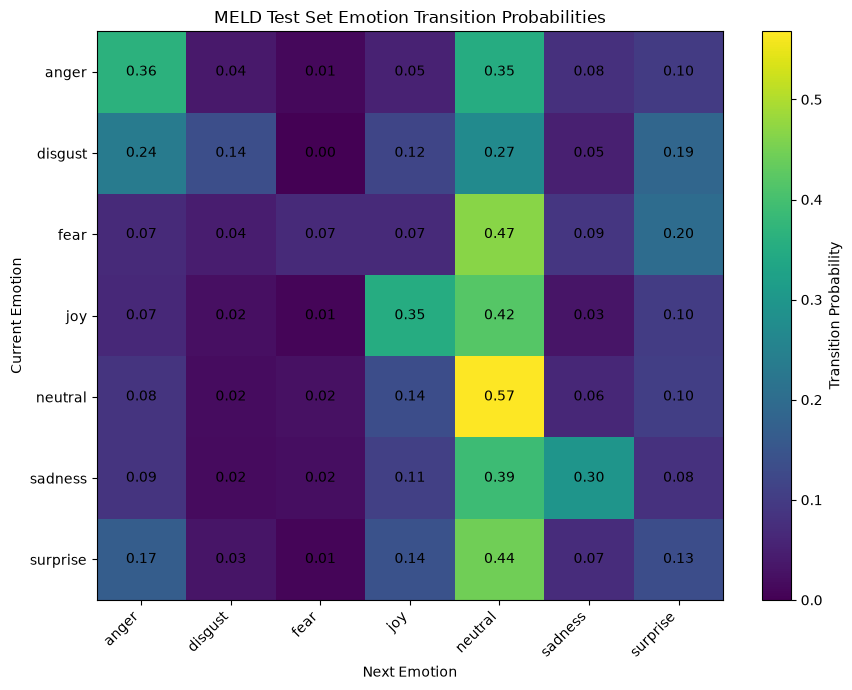

In [9]:
import matplotlib.pyplot as plt

test_transitions = build_valid_transitions(dataset.test)
test_probabilities = transition_probabilities(test_transitions)

plt.figure(figsize=(9, 7))
plt.imshow(test_probabilities.values, aspect="auto")

plt.xticks(
    range(len(test_probabilities.columns)),
    test_probabilities.columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(test_probabilities.index)),
    test_probabilities.index,
)

plt.xlabel("Next Emotion")
plt.ylabel("Current Emotion")
plt.title("MELD Test Set Emotion Transition Probabilities")

for i in range(len(test_probabilities.index)):
    for j in range(len(test_probabilities.columns)):
        plt.text(
            j,
            i,
            f"{test_probabilities.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

plt.colorbar(label="Transition Probability")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figures" / "week7_test_transition_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [10]:
persistence_rows = []

for name, df in splits.items():
    transitions = build_valid_transitions(df)
    result = calculate_persistence(transitions)

    for emotion, values in result["per_emotion"].items():
        persistence_rows.append({
            "split": name,
            "emotion": emotion,
            "persistence_rate": values["persistence_rate"],
            "transitions": values["transitions"],
        })

per_emotion_persistence = pd.DataFrame(persistence_rows)

test_persistence = per_emotion_persistence[
    per_emotion_persistence["split"] == "test"
]

test_persistence

,split,emotion,persistence_rate,transitions
14,test,anger,0.364217,313
15,test,disgust,0.135593,59
16,test,fear,0.066667,45
17,test,joy,0.352436,349
18,test,neutral,0.568000,1125
19,test,sadness,0.297297,185
20,test,surprise,0.134921,252


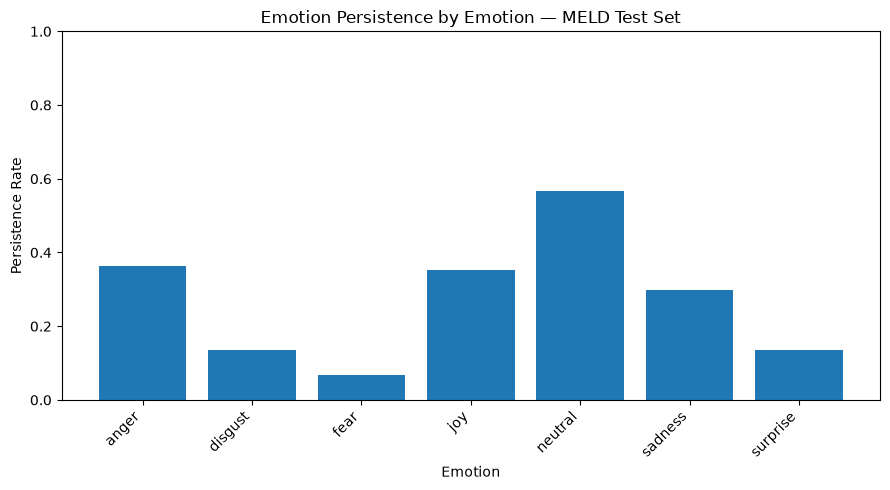

In [11]:
plt.figure(figsize=(9, 5))

plt.bar(
    test_persistence["emotion"],
    test_persistence["persistence_rate"],
)

plt.ylabel("Persistence Rate")
plt.xlabel("Emotion")
plt.title("Emotion Persistence by Emotion — MELD Test Set")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figures" / "week7_emotion_persistence.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()